## **Section 1: Import Required Libraries**

In [59]:
# =====================================================================
# SECTION 1: SYSTEM LIBRARIES & DEPENDENCY INITIALIZATION
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, make_scorer, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Global figure style — controls both display size and export quality
plt.rcParams.update({
    'font.family'    : 'DejaVu Sans',
    'font.size'      : 10,
    'axes.titlesize' : 11,
    'axes.labelsize' : 10,
    'figure.dpi'     : 120,        # screen display size — keeps figures compact in notebook
    'savefig.dpi'    : 300,       # export quality — all saved TIFFs at 300 DPI
    'figure.figsize' : (5, 4),    # default size for all single plots
})
sns.set_theme(style='ticks', context='paper', font_scale=1.0)

TIFF_DPI = 300

print('[OK] All libraries imported successfully.')

[OK] All libraries imported successfully.


## **Section2:  Clinical Data Processing and Outcome Definition**

Clinical survival data were cleaned and standardized prior to analysis. Patient identifiers were converted to the standard 12-character TCGA barcode format to ensure consistency across clinical, mRNA, and miRNA datasets. Duplicate records were removed, and patients lacking valid survival information were excluded.



To formulate a supervised machine learning problem, overall survival time was converted into a binary outcome. Patients surviving longer than the cohort median were assigned to the favorable prognosis group, whereas those surviving for a shorter period were assigned to the poor prognosis group. This binary target variable was subsequently used for model training and evaluation.

--- SECTION 2: RUNNING CLINICAL DATA PIPELINE ---
[METRIC] Initial raw clinical records loaded: 651 rows.
[METRIC] Unique deduplicated patients with valid survival data: 187

[STATS] Survival Time Distribution (days):
count     187.0000
mean      560.4278
std       587.9780
min         0.0000
25%       153.0000
50%       365.0000
75%       746.0000
max      2861.0000

[BIOLOGY] Cohort median survival cutoff: 365 days

[CLASS DISTRIBUTION]
  Poor Prognosis      (0 — ≤ median): 98 patients
  Favorable Prognosis (1 — >  median): 89 patients

--- CLINICAL TARGET PREVIEW (First 5 Patients) ---
PatientID
TCGA-AB-2934    0
TCGA-AB-2840    0
TCGA-AB-2972    0
TCGA-AB-2909    0
TCGA-AB-2988    0


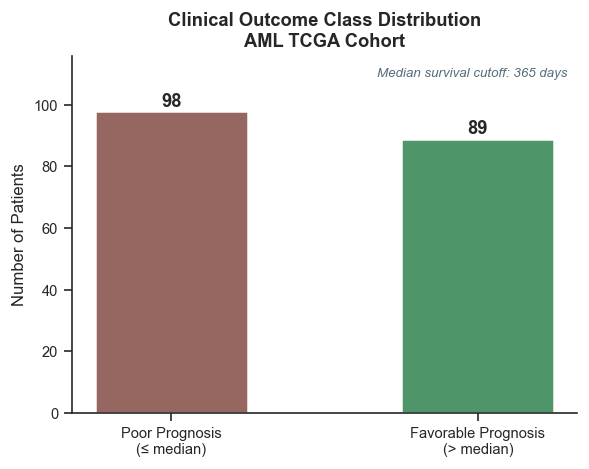

In [79]:
# =====================================================================
# SECTION 2: CLINICAL DATA CLEANING
# =====================================================================
print("--- SECTION 2: RUNNING CLINICAL DATA PIPELINE ---")

# 1. Load raw clinical matrix
raw_survival = pd.read_csv('survival', sep='\t')
print(f"[METRIC] Initial raw clinical records loaded: {raw_survival.shape[0]} rows.")

# 2. Standardize to 12-character TCGA barcodes
raw_survival['PatientID'] = raw_survival['PatientID'].str.replace('"', '').str[:12]

# 3. Deduplicate
clean_survival = raw_survival.drop_duplicates(subset=['PatientID'], keep='first').copy()

# 4. Coerce survival to numeric; drop missing
clean_survival['Survival'] = pd.to_numeric(clean_survival['Survival'], errors='coerce')
clean_survival = clean_survival.dropna(subset=['Survival'])
print(f"[METRIC] Unique deduplicated patients with valid survival data: {len(clean_survival)}")

# 5. Survival statistics
print("\n[STATS] Survival Time Distribution (days):")
print(clean_survival['Survival'].describe().round(4).to_string())

# 6. Median-split binary target
cohort_median_days = clean_survival['Survival'].median()
print(f"\n[BIOLOGY] Cohort median survival cutoff: {cohort_median_days:.0f} days")
clean_survival['Target'] = (clean_survival['Survival'] > cohort_median_days).astype(int)
clinical_target   = clean_survival.set_index('PatientID')['Target']


# 7. save survival and death information for Kaplan-Meier analysis
clinical_survival = clean_survival.set_index('PatientID')['Survival']
clinical_death    = clean_survival.set_index('PatientID')['Death']

print("\n[CLASS DISTRIBUTION]")
vc = clean_survival['Target'].value_counts().sort_index()
print(f"  Poor Prognosis      (0 — ≤ median): {vc[0]} patients")
print(f"  Favorable Prognosis (1 — >  median): {vc[1]} patients")

print("\n--- CLINICAL TARGET PREVIEW (First 5 Patients) ---")
print(clinical_target.head(5).to_string())

# ── Figure: Outcome Class Distribution ───────────────────────────────
fig2, ax2 = plt.subplots(figsize=(5, 4))
bars = ax2.bar(['Poor Prognosis\n(≤ median)', 'Favorable Prognosis\n(> median)'],
               [vc[0], vc[1]],
               color=["#661F16AE", "#05682BB3"],
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, [vc[0], vc[1]]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5, str(val),
             ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Patients', fontsize=10)
ax2.set_title('Clinical Outcome Class Distribution\nAML TCGA Cohort',
              fontsize=11, fontweight='bold')
ax2.set_ylim(0, max(vc[0], vc[1]) * 1.18)
ax2.text(0.98, 0.97,
         f'Median survival cutoff: {cohort_median_days:.0f} days',
         transform=ax2.transAxes, fontsize=8, color='#546E7A',
         ha='right', va='top', style='italic')
sns.despine(ax=ax2)
plt.tight_layout()
plt.savefig('Figure1_Clinical_Outcome_Distribution.tiff', dpi=TIFF_DPI, bbox_inches='tight')
plt.show()


## **Interpretation:**

After data cleaning and removal of duplicate patient records, 187 AML patients with valid survival information were retained for downstream analysis.
25% = 153 days\
50% = 365 days\
75% = 746 days


This shows strong heterogeneity among AML patients.
Survival times varied substantially across the cohort, ranging from 0 to 2861 days. This broad distribution reflects the biological and clinical heterogeneity of AML, where patients with the same diagnosis can experience markedly different disease trajectories and outcomes.

Some AML patients survive only a few months, whereas others survive several years despite having the same disease diagnosis.

## **Section 3: mRNA Expression Preprocessing**
Raw RNA-seq expression data were standardized prior to downstream analysis. Patient identifiers were converted to the TCGA barcode format used throughout the study, and multiple samples belonging to the same patient were averaged to obtain a single expression profile per individual.

Expression values were log2-transformed to reduce the influence of highly expressed genes and stabilize variance across the dataset. To reduce dimensionality and limit noise, the 500 most variable genes were retained for downstream analyses. These genes are more likely to capture biologically meaningful variation between AML patients and provide informative features for machine learning models.


--- SECTION 3: PARSING GENOMIC TRANSCRIPT DATA ---
[METRIC] Raw input: 20531 genes × 173 sample vials.
[METRIC] After transpose & averaging: 173 patients × 20531 genes.


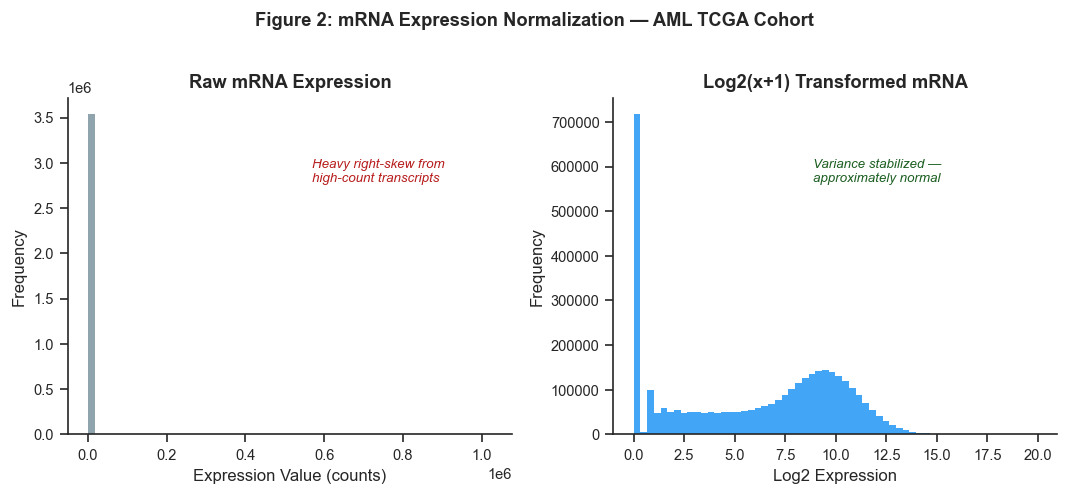

[OUTPUT] Figure 2 saved → Figure2_mRNA_Normalization.tiff

[STATS] Gene Variance Distribution (post-log2):
count    20531.0000
mean         1.2152
std          1.8693
min          0.0000
25%          0.1977
50%          0.4828
75%          1.4684
max         47.7095


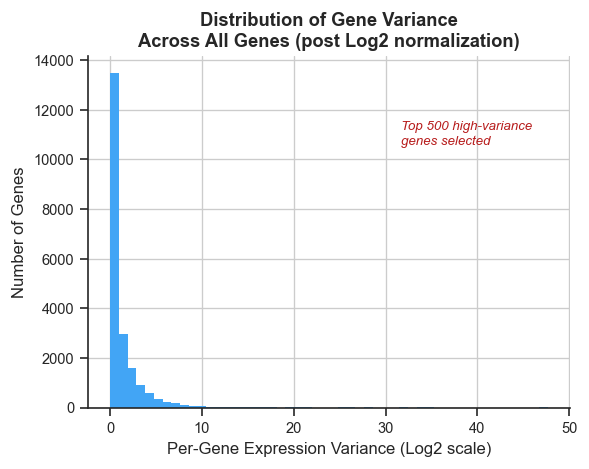

[OUTPUT] Figure 2b saved → Figure2b_Gene_Variance_Distribution.tiff

[METRIC] Final mRNA matrix: 173 patients × 500 high-variance genes.

--- mRNA MATRIX PREVIEW (3 patients × 3 genes) ---
              mRNA_XIST.7503  mRNA_KDM5D.8284  mRNA_DDX3Y.8653
TCGA-AB-2803         16.0014           0.0000           0.0000
TCGA-AB-2805          0.9981          12.0139          11.1642
TCGA-AB-2806          0.0000           6.5922           6.9450

--- SECTION 3 COMPLETE ---


In [44]:
# =====================================================================
# SECTION 3: mRNA LAYER EXPANSION, TRANSFORMATION & FILTERING
# =====================================================================
print("\n--- SECTION 3: PARSING GENOMIC TRANSCRIPT DATA ---")

# 1. Load raw expression table
raw_mrna = pd.read_csv('exp', sep=r'\s+', index_col=0)
raw_mrna.index = raw_mrna.index.astype(str).str.replace('"', '')
print(f"[METRIC] Raw input: {raw_mrna.shape[0]} genes × {raw_mrna.shape[1]} sample vials.")

# 2. Standardize sample IDs to 12-char patient barcodes
raw_mrna.columns = [col.replace('"', '').replace('.', '-')[:12] for col in raw_mrna.columns]

# 3. Transpose → patients as rows; average technical duplicates
mrna_transposed       = raw_mrna.T
mrna_patient_averaged = mrna_transposed.groupby(mrna_transposed.index).mean()
print(f"[METRIC] After transpose & averaging: "
      f"{mrna_patient_averaged.shape[0]} patients × {mrna_patient_averaged.shape[1]} genes.")

# 4. Log2 normalization
mrna_log_scaled = np.log2(mrna_patient_averaged + 1)

# ── Figure: mRNA Normalization Comparison (Raw vs Log2) ──────────────
fig3a, axes3a = plt.subplots(1, 2, figsize=(9, 4))
axes3a[0].hist(mrna_patient_averaged.values.flatten(), bins=60,
               color='#90A4AE', edgecolor='none')
axes3a[0].set_title('Raw mRNA Expression', fontsize=11, fontweight='bold')
axes3a[0].set_xlabel('Expression Value (counts)', fontsize=10)
axes3a[0].set_ylabel('Frequency', fontsize=10)
axes3a[0].annotate('Heavy right-skew from\nhigh-count transcripts',
                   xy=(0.55, 0.75), xycoords='axes fraction',
                   fontsize=8, color='#B71C1C', style='italic')

axes3a[1].hist(mrna_log_scaled.values.flatten(), bins=60,
               color='#42A5F5', edgecolor='none')
axes3a[1].set_title('Log2(x+1) Transformed mRNA', fontsize=11, fontweight='bold')
axes3a[1].set_xlabel('Log2 Expression', fontsize=10)
axes3a[1].set_ylabel('Frequency', fontsize=10)
axes3a[1].annotate('Variance stabilized —\napproximately normal',
                   xy=(0.45, 0.75), xycoords='axes fraction',
                   fontsize=8, color='#1B5E20', style='italic')

for ax in axes3a:
    sns.despine(ax=ax)
fig3a.suptitle('Figure 2: mRNA Expression Normalization — AML TCGA Cohort',
               fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Figure2_mRNA_Normalization.tiff', bbox_inches='tight')
plt.show()
print("[OUTPUT] Figure 2 saved → Figure2_mRNA_Normalization.tiff")

# 5. Variance summary & distribution
print("\n[STATS] Gene Variance Distribution (post-log2):")
print(mrna_log_scaled.var(axis=0).describe().round(4).to_string())

# ── Figure: Gene Variance Distribution ───────────────────────────────
fig3b, ax3b = plt.subplots(figsize=(5, 4))
mrna_log_scaled.var(axis=0).hist(bins=50, ax=ax3b,
                                  color='#42A5F5', edgecolor='none')
ax3b.set_title('Distribution of Gene Variance\nAcross All Genes (post Log2 normalization)',
               fontsize=11, fontweight='bold')
ax3b.set_xlabel('Per-Gene Expression Variance (Log2 scale)', fontsize=10)
ax3b.set_ylabel('Number of Genes', fontsize=10)
ax3b.annotate('Top 500 high-variance\ngenes selected',
              xy=(0.65, 0.75), xycoords='axes fraction',
              fontsize=8, color='#B71C1C', style='italic')
sns.despine(ax=ax3b)
plt.tight_layout()
plt.savefig('Figure2b_Gene_Variance_Distribution.tiff', bbox_inches='tight')
plt.show()
print("[OUTPUT] Figure 2b saved → Figure2b_Gene_Variance_Distribution.tiff")

# 6. Top-500 feature selection
top_variance_genes = mrna_log_scaled.var(axis=0).nlargest(500).index
mrna_clean_matrix  = mrna_log_scaled[top_variance_genes].add_prefix("mRNA_")
print(f"\n[METRIC] Final mRNA matrix: {mrna_clean_matrix.shape[0]} patients × "
      f"{mrna_clean_matrix.shape[1]} high-variance genes.")

print("\n--- mRNA MATRIX PREVIEW (3 patients × 3 genes) ---")
print(mrna_clean_matrix.iloc[:3, :3].round(4).to_string())
print("\n--- SECTION 3 COMPLETE ---")

## **Interpretation:**

Genes exhibiting greater variability across patients are more likely to reflect underlying biological differences associated with disease progression, molecular subtypes, and clinical outcome. Therefore, the 500 most variable genes were retained to enrich the dataset for informative signals while reducing noise from genes with relatively stable expression patterns.

## **Section 4: miRNA Expression Preprocessing**

miRNAs are key post-transcriptional regulators that influence gene expression and play important roles in AML development and progression. Similar preprocessing steps were applied to the miRNA dataset to ensure consistency across omics layers.


Patient identifiers were standardized, duplicate patient samples were averaged, and expression values were log2-transformed to reduce skewness and stabilize variance. To reduce dimensionality and focus on the most informative regulatory signals, the 100 most variable miRNAs were retained for downstream machine learning analyses.


--- SECTION 4: PARSING REGULATORY MICRO-RNA DATA ---
[METRIC] Raw input: 705 miRNAs × 188 sample vials.


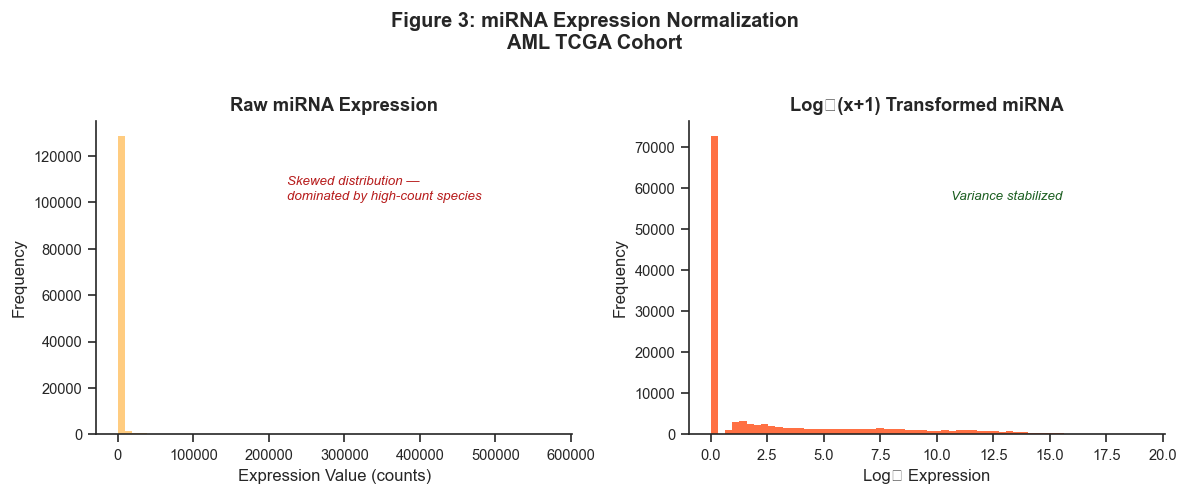

[OUTPUT] Figure 3 saved → Figure3_miRNA_Normalization.tiff

[STATS] miRNA Variance Distribution (post-log2):
count    705.0000
mean       1.0700
std        1.6357
min        0.0000
25%        0.0124
50%        0.4614
75%        1.2963
max        9.6158

[METRIC] Final miRNA matrix: 188 patients × 100 high-variance miRNAs.
[METRIC] Unique AML patients retained: 188

--- miRNA MATRIX PREVIEW (3 patients × 3 miRNAs) ---
              miRNA_hsa.mir.10a  miRNA_hsa.mir.379  miRNA_hsa.mir.100
TCGA-AB-2802            18.2128             4.7469             7.3953
TCGA-AB-2803            10.7897            13.1467            17.2760
TCGA-AB-2805            15.0139             4.7979             6.4398

--- SECTION 4 COMPLETE ---


In [45]:
# =====================================================================
# SECTION 4: miRNA LAYER EXPANSION, TRANSFORMATION & FILTERING
# =====================================================================
print("\n--- SECTION 4: PARSING REGULATORY MICRO-RNA DATA ---")

# 1. Load raw miRNA table
raw_mirna = pd.read_csv('mirna', sep=r'\s+', index_col=0)
raw_mirna.index = raw_mirna.index.astype(str).str.replace('"', '')
print(f"[METRIC] Raw input: {raw_mirna.shape[0]} miRNAs × {raw_mirna.shape[1]} sample vials.")

# 2. Standardize IDs
raw_mirna.columns = [col.replace('"', '').replace('.', '-')[:12] for col in raw_mirna.columns]

# 3. Transpose & average duplicates
mirna_transposed       = raw_mirna.T
mirna_patient_averaged = mirna_transposed.groupby(mirna_transposed.index).mean()

# 4. Log2 normalization
mirna_log_scaled = np.log2(mirna_patient_averaged + 1)

# ── Figure: miRNA Normalization Comparison ───────────────────────────
fig4, axes4 = plt.subplots(1, 2, figsize=(10, 4))
axes4[0].hist(mirna_patient_averaged.values.flatten(), bins=60,
              color='#FFCC80', edgecolor='none')
axes4[0].set_title('Raw miRNA Expression', fontsize=11, fontweight='bold')
axes4[0].set_xlabel('Expression Value (counts)', fontsize=10)
axes4[0].set_ylabel('Frequency', fontsize=10)
axes4[0].annotate('Skewed distribution —\ndominated by high-count species',
                  xy=(0.40, 0.75), xycoords='axes fraction',
                  fontsize=8, color='#B71C1C', style='italic')

axes4[1].hist(mirna_log_scaled.values.flatten(), bins=60,
              color='#FF7043', edgecolor='none')
axes4[1].set_title('Log₂(x+1) Transformed miRNA', fontsize=11, fontweight='bold')
axes4[1].set_xlabel('Log₂ Expression', fontsize=10)
axes4[1].set_ylabel('Frequency', fontsize=10)
axes4[1].annotate('Variance stabilized',
                  xy=(0.55, 0.75), xycoords='axes fraction',
                  fontsize=8, color='#1B5E20', style='italic')

for ax in axes4:
    sns.despine(ax=ax)
fig4.suptitle('Figure 3: miRNA Expression Normalization\nAML TCGA Cohort',
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Figure3_miRNA_Normalization.tiff', dpi=TIFF_DPI, bbox_inches='tight')
plt.show()
print("[OUTPUT] Figure 3 saved → Figure3_miRNA_Normalization.tiff")

# 5. Variance summary & top-100 feature selection
print("\n[STATS] miRNA Variance Distribution (post-log2):")
print(mirna_log_scaled.var(axis=0).describe().round(4).to_string())

top_variance_mirnas = mirna_log_scaled.var(axis=0).nlargest(100).index
mirna_clean_matrix  = mirna_log_scaled[top_variance_mirnas].add_prefix("miRNA_")
print(f"\n[METRIC] Final miRNA matrix: {mirna_clean_matrix.shape[0]} patients × "
      f"{mirna_clean_matrix.shape[1]} high-variance miRNAs.")
print(f"[METRIC] Unique AML patients retained: {mirna_clean_matrix.shape[0]}")

print("\n--- miRNA MATRIX PREVIEW (3 patients × 3 miRNAs) ---")
print(mirna_clean_matrix.iloc[:3, :3].round(4).to_string())
print("\n--- SECTION 4 COMPLETE ---")

## **Interpretation:**

Most miRNAs exhibited low variability across AML patients,
whereas a smaller subset showed substantially higher variance.

Highly variable miRNAs were prioritized because they are more likely to represent regulatory differences between AML patients and may contribute to disease progression, prognosis, and treatment response because they are
more likely to capture biologically relevant regulatory differences
and contribute informative signals for downstream machine learning analyses.

miRNAs are important post-transcriptional regulators that influence multiple downstream genes simultaneously, making them attractive biomarkers in precision medicine.

## **Section 5: Multi-Omics Data Integration**

To generate a unified analytical dataset, patient identifiers were matched across the clinical, mRNA, and miRNA datasets. Only patients with complete information in all three data sources were retained to ensure consistency and eliminate missing values.

The filtered mRNA and miRNA matrices were concatenated to form a single multi-omics feature matrix. The filtered mRNA and miRNA matrices were concatenated to generate a unified multi-omics feature matrix. To avoid information leakage during model development, feature scaling was deferred to the machine learning pipeline and applied only where required. This preprocessing step is particularly important for machine learning algorithms that are sensitive to differences in feature magnitude.


--- SECTION 5: ALIGNING MULTI-OMICS LAYERS SIDE-BY-SIDE ---
[BIOLOGY] Found exactly 162 unique patients with complete profiles in all 3 systems.
[METRIC] Integrated Feature Matrix (X) Shape: (162, 600) (500 mRNA + 100 miRNA features)
[METRIC] Target Vector (y) Shape: (162,)

Class Distribution After Integration:
Target
Poor Prognosis (0)         84
Favorable Prognosis (1)    78
Name: count, dtype: int64

Missing Values in X: 0

--- MULTI-OMICS PREVIEW (2 patients × 2 mRNA + 2 miRNA features) ---
              mRNA_XIST.7503  mRNA_KDM5D.8284  miRNA_hsa.mir.10a  \
TCGA-AB-2803          1.0970          -1.0865            -1.1162   
TCGA-AB-2805         -1.0845           0.9670             0.2365   

              miRNA_hsa.mir.379  
TCGA-AB-2803             2.4390  
TCGA-AB-2805            -0.3322  


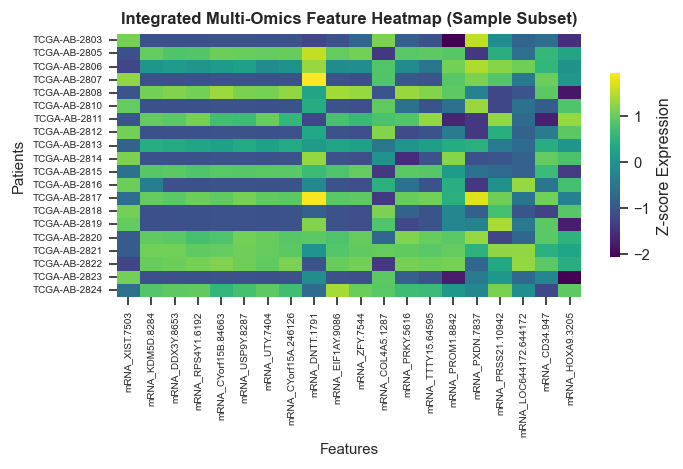

In [56]:
# =====================================================================
# SECTION 5: MULTI-OMICS INTEGRATION & Z-SCORE SCALING
# =====================================================================
print("\n--- SECTION 5: ALIGNING MULTI-OMICS LAYERS SIDE-BY-SIDE ---")

# 1. Three-way patient intersection
perfectly_aligned_patients = (mrna_clean_matrix.index
    .intersection(mirna_clean_matrix.index)
    .intersection(clinical_target.index))
print(f"[BIOLOGY] Found exactly {len(perfectly_aligned_patients)} unique patients with complete profiles in all 3 systems.")

# 2. Concatenate mRNA + miRNA feature matrices
X_unscaled = pd.concat([mrna_clean_matrix.loc[perfectly_aligned_patients],
                         mirna_clean_matrix.loc[perfectly_aligned_patients]], axis=1)
y = clinical_target.loc[perfectly_aligned_patients]

# 3. Z-score normalization (μ=0, σ=1)
z_scaler = StandardScaler()
X = pd.DataFrame(z_scaler.fit_transform(X_unscaled),
                 index=X_unscaled.index, columns=X_unscaled.columns)

print(f"[METRIC] Integrated Feature Matrix (X) Shape: {X.shape} (500 mRNA + 100 miRNA features)")
print(f"[METRIC] Target Vector (y) Shape: {y.shape}")
print("\nClass Distribution After Integration:")
print(y.value_counts().rename({0: 'Poor Prognosis (0)', 1: 'Favorable Prognosis (1)'}))
print(f"\nMissing Values in X: {X.isnull().sum().sum()}")

# Preview: explicitly show 2 mRNA + 2 miRNA columns
mrna_cols  = [c for c in X.columns if c.startswith('mRNA_')][:2]
mirna_cols = [c for c in X.columns if c.startswith('miRNA_')][:2]
print("\n--- MULTI-OMICS PREVIEW (2 patients × 2 mRNA + 2 miRNA features) ---")
print(X.loc[perfectly_aligned_patients[:2], mrna_cols + mirna_cols].round(4))

# ── Figure 4a: Multi-Omics Heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(X.iloc[:20, :20], cmap='viridis', ax=ax,
            xticklabels=True, yticklabels=True,
            linewidths=0, linecolor='none',
            cbar_kws={'label': 'Z-score Expression', 'shrink': 0.7})
ax.set_title('Integrated Multi-Omics Feature Heatmap (Sample Subset)', fontsize=10, fontweight='bold')
ax.set_xlabel('Features', fontsize=9)
ax.set_ylabel('Patients', fontsize=9)
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6, rotation=0)
plt.tight_layout()
plt.savefig('Figure4a_MultiOmics_Heatmap.tiff', bbox_inches='tight')
plt.show()




After harmonization across clinical, mRNA, and miRNA datasets, 162 AML patients with complete multi-omics profiles were retained for downstream analyses.

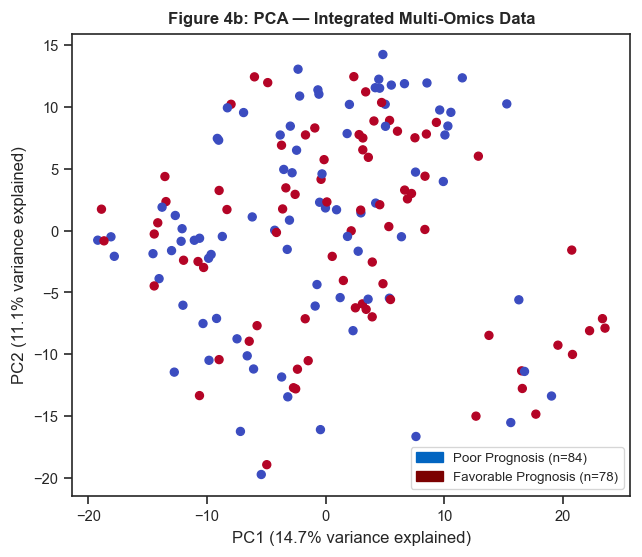

In [76]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm')
plt.title('Figure 4b: PCA — Integrated Multi-Omics Data', fontsize=10, fontweight='bold')
plt.xlabel(f'PC1 ({var_exp[0]:.1f}% variance explained)', fontsize=10)
plt.ylabel(f'PC2 ({var_exp[1]:.1f}% variance explained)', fontsize=10)
plt.legend(handles=[
    mpatches.Patch(color="#0265C1", label=f'Poor Prognosis (n={(y==0).sum()})'),
    mpatches.Patch(color="#7C0101", label=f'Favorable Prognosis (n={(y==1).sum()})')
], fontsize=8, frameon=True)
plt.savefig("Figure4b_PCA_Multiomics.tiff", bbox_inches='tight')
plt.show()

## **Interpretation:**

PCA was used as an unsupervised dimensionality reduction technique to visualize global patterns within the integrated multi-omics dataset and assess whether survival groups exhibit distinct molecular profiles.

## **Section 6: Machine Learning Model Development & Evaluation**

Three algorithms are evaluated for AML survival prediction from integrated mRNA and miRNA profiles: Random Forest, XGBoost, and SVM (with StandardScaler pipeline).

**Stage 1 — Single Split:** Stratified 75/25 split (121 train / 41 test). Initial performance signal and ROC curves.

**Stage 2 — 5-Fold CV:** All 162 patients, 5 stratified folds, tuned hyperparameters. Mean ± SD AUC confirms reliability.

**Metrics:** AUC, F1, Precision, Recall, Sensitivity, Specificity.

**Figures:**
- Figure 5: ROC curves — single split
- Figure 6: AUC comparison + full CV metrics — combined



--- SECTION 6: MACHINE LEARNING MODEL DEVELOPMENT ---
[METRIC] Training patients : 121
[METRIC] Test patients     : 41
[METRIC] Total features    : 600 (500 mRNA + 100 miRNA)

  Training class distribution:
    Poor Prognosis      (0): 63
    Favorable Prognosis (1): 58

  Test class distribution:
    Poor Prognosis      (0): 21
    Favorable Prognosis (1): 20

   STAGE 1: SINGLE SPLIT EVALUATION  (test n=41)

  [Random Forest]
    Accuracy    : 61.0%
    AUC         : 0.579
    Sensitivity : 0.450  (Poor prognosis detection)
    Specificity : 0.762  (Favorable prognosis detection)
    FN — missed poor prognosis patients: 11  ← critical

  [XGBoost]
    Accuracy    : 70.7%
    AUC         : 0.726
    Sensitivity : 0.650  (Poor prognosis detection)
    Specificity : 0.762  (Favorable prognosis detection)
    FN — missed poor prognosis patients: 7  ← critical

  [Support Vector Machine]
    Accuracy    : 53.7%
    AUC         : 0.550
    Sensitivity : 0.450  (Poor prognosis detection)
 

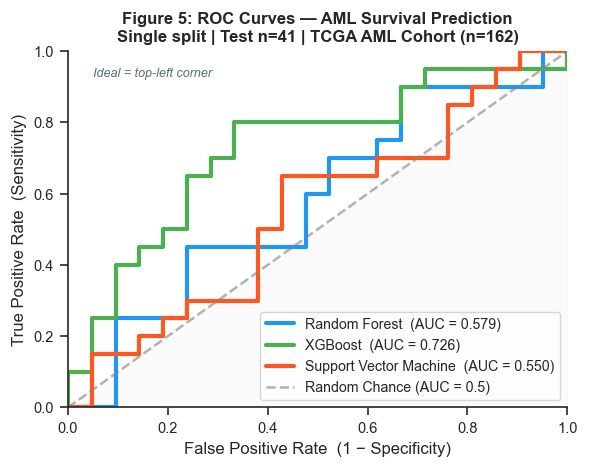

[OUTPUT] Figure 5 saved → Figure5_ROC_Curves.tiff

   STAGE 2: 5-FOLD CROSS-VALIDATION  (tuned models)

  [Random Forest]
    AUC       : 0.611 ± 0.052
    F1        : 0.571 ± 0.072
    Precision : 0.587 ± 0.053
    Recall    : 0.566 ± 0.109

  [XGBoost]
    AUC       : 0.619 ± 0.023
    F1        : 0.582 ± 0.031
    Precision : 0.581 ± 0.047
    Recall    : 0.592 ± 0.065

  [Support Vector Machine]
    AUC       : 0.640 ± 0.071
    F1        : 0.544 ± 0.047
    Precision : 0.583 ± 0.048
    Recall    : 0.515 ± 0.073

  ----------------------------------------------------------
  SINGLE SPLIT → 5-FOLD CV  (AUC)
  ----------------------------------------------------------
  Random Forest                  0.579 → 0.611 ± 0.052  ▲ 0.033
  XGBoost                        0.726 → 0.619 ± 0.023  ▼ 0.108
  Support Vector Machine         0.550 → 0.640 ± 0.071  ▲ 0.090

  INTERPRETATION:
  XGBoost drop: single-split AUC was inflated by test composition.
  SVM improvement: RBF kernel better suits

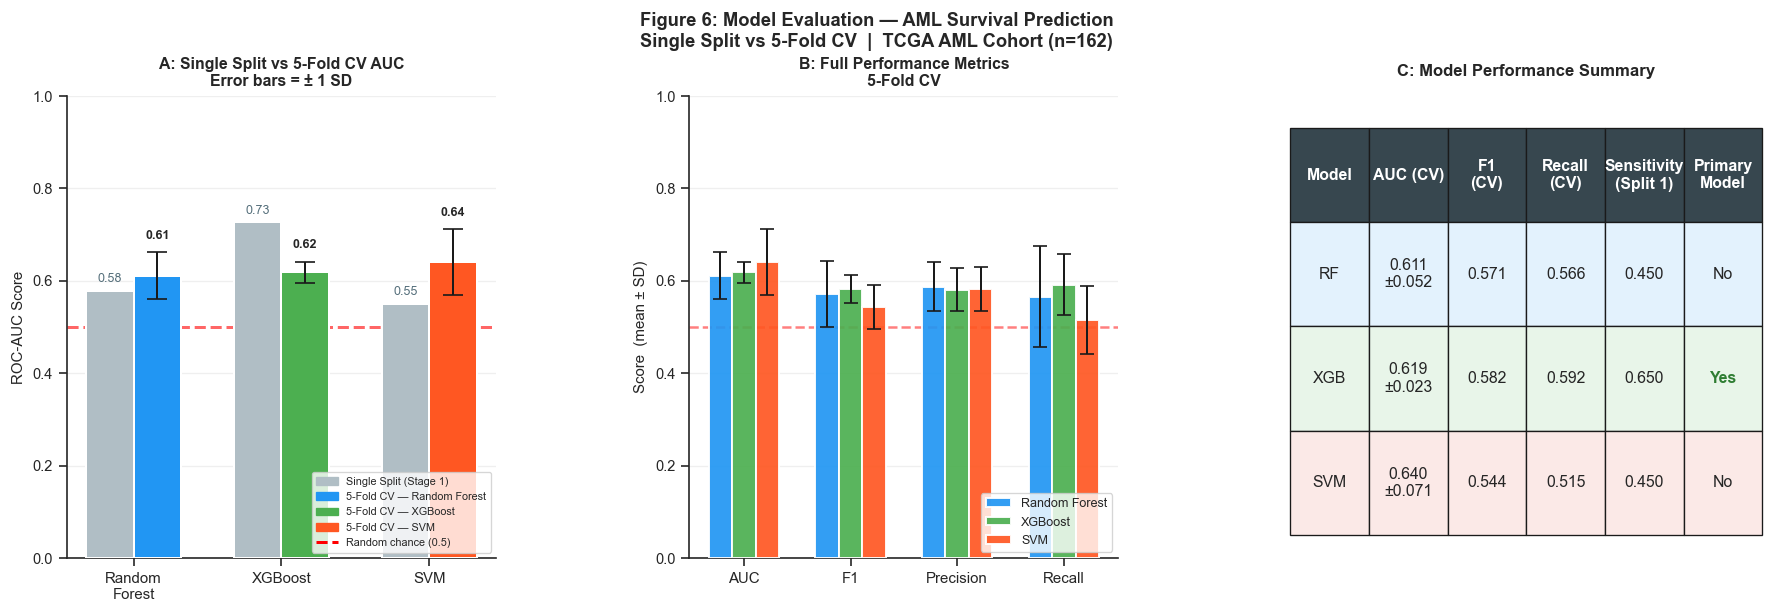

[OUTPUT] Figure 6 saved → Figure6_Model_Evaluation.tiff

   SECTION 6 COMPLETE — 2 FIGURES EXPORTED
  Figure 5 → Figure5_ROC_Curves.tiff
  Figure 6 → Figure6_Model_Evaluation.tiff

  Primary model: XGBoost
  Rationale: best F1 + lowest CV variance (±0.023)

--- SECTION 6 COMPLETE ---


In [61]:
# =====================================================================
# SECTION 6: MACHINE LEARNING MODEL DEVELOPMENT & EVALUATION
# =====================================================================
print("\n--- SECTION 6: MACHINE LEARNING MODEL DEVELOPMENT ---")

# ─────────────────────────────────────────────────────────────────────
# 6.1  STRATIFIED TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"[METRIC] Training patients : {X_train.shape[0]}")
print(f"[METRIC] Test patients     : {X_test.shape[0]}")
print(f"[METRIC] Total features    : {X_train.shape[1]} (500 mRNA + 100 miRNA)")
print("\n  Training class distribution:")
print(f"    Poor Prognosis      (0): {(y_train==0).sum()}")
print(f"    Favorable Prognosis (1): {(y_train==1).sum()}")
print("\n  Test class distribution:")
print(f"    Poor Prognosis      (0): {(y_test==0).sum()}")
print(f"    Favorable Prognosis (1): {(y_test==1).sum()}")

# ─────────────────────────────────────────────────────────────────────
# 6.2  MODEL INITIALIZATION
# ─────────────────────────────────────────────────────────────────────
rf_classifier = RandomForestClassifier(
    n_estimators=200, max_depth=5, random_state=42
)
xgb_classifier = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    eval_metric='logloss', random_state=42
)
svm_classifier = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='linear', C=0.1,
                   probability=True, random_state=42))
])

models = {
    'Random Forest'         : rf_classifier,
    'XGBoost'               : xgb_classifier,
    'Support Vector Machine': svm_classifier
}
colors_model = ['#2196F3', '#4CAF50', '#FF5722']

# ─────────────────────────────────────────────────────────────────────
# 6.3  STAGE 1 — SINGLE SPLIT EVALUATION
# ─────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("   STAGE 1: SINGLE SPLIT EVALUATION  (test n=41)")
print("="*65)

section6_auc     = {}
section6_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds          = model.predict(X_test)
    probs          = model.predict_proba(X_test)[:, 1]
    cm             = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    auc  = roc_auc_score(y_test, probs)
    acc  = accuracy_score(y_test, preds)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    section6_auc[name]     = auc
    section6_results[name] = {
        'probs': probs, 'preds': preds, 'cm': cm,
        'auc': auc, 'acc': acc, 'sens': sens, 'spec': spec,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }
    print(f"\n  [{name}]")
    print(f"    Accuracy    : {acc*100:.1f}%")
    print(f"    AUC         : {auc:.3f}")
    print(f"    Sensitivity : {sens:.3f}  (Poor prognosis detection)")
    print(f"    Specificity : {spec:.3f}  (Favorable prognosis detection)")
    print(f"    FN — missed poor prognosis patients: {fn}  ← critical")

# ─────────────────────────────────────────────────────────────────────
# FIGURE 5: ROC Curves — Single Split
# ─────────────────────────────────────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(5, 4))

for (name, res), color in zip(section6_results.items(), colors_model):
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    ax5.plot(fpr, tpr,
             label=f"{name}  (AUC = {res['auc']:.3f})",
             lw=2.5, color=color)

ax5.plot([0,1],[0,1], color='grey', linestyle='--',
         lw=1.5, alpha=0.6, label='Random Chance (AUC = 0.5)')
ax5.fill_between([0,1],[0,1], alpha=0.04, color='grey')
ax5.set_xlabel('False Positive Rate  (1 − Specificity)', fontsize=10)
ax5.set_ylabel('True Positive Rate  (Sensitivity)', fontsize=10)
ax5.set_title('Figure 5: ROC Curves — AML Survival Prediction\n'
              'Single split | Test n=41 | TCGA AML Cohort (n=162)',
              fontsize=10, fontweight='bold')
ax5.legend(loc='lower right', fontsize=8.5, frameon=True)
ax5.annotate('Ideal = top-left corner',
             xy=(0.05, 0.93), fontsize=7.5,
             color='#546E7A', style='italic')
ax5.set_xlim(0,1); ax5.set_ylim(0,1)
sns.despine(ax=ax5)
plt.tight_layout()
plt.savefig('Figure5_ROC_Curves.tiff', bbox_inches='tight', dpi=300)
plt.show()
print("[OUTPUT] Figure 5 saved → Figure5_ROC_Curves.tiff")

# ─────────────────────────────────────────────────────────────────────
# 6.4  STAGE 2 — 5-FOLD CROSS-VALIDATION WITH TUNED MODELS
# ─────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("   STAGE 2: 5-FOLD CROSS-VALIDATION  (tuned models)")
print("="*65)

tuned_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=3,
        max_features='sqrt', random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    ),
    'Support Vector Machine': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  SVC(kernel='rbf', C=1.0, gamma='scale',
                       probability=True, random_state=42))
    ])
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'AUC'      : 'roc_auc',
    'F1'       : make_scorer(f1_score),
    'Precision': make_scorer(precision_score, zero_division=0),
    'Recall'   : make_scorer(recall_score)
}

cv_results = {}
print()
for name, model in tuned_models.items():
    scores = cross_validate(model, X, y, cv=cv_strategy,
                            scoring=scoring,
                            return_train_score=False, n_jobs=-1)
    cv_results[name] = scores
    print(f"  [{name}]")
    print(f"    AUC       : {scores['test_AUC'].mean():.3f} "
          f"± {scores['test_AUC'].std():.3f}")
    print(f"    F1        : {scores['test_F1'].mean():.3f} "
          f"± {scores['test_F1'].std():.3f}")
    print(f"    Precision : {scores['test_Precision'].mean():.3f} "
          f"± {scores['test_Precision'].std():.3f}")
    print(f"    Recall    : {scores['test_Recall'].mean():.3f} "
          f"± {scores['test_Recall'].std():.3f}")
    print()

# Improvement summary
print("  " + "-"*58)
print("  SINGLE SPLIT → 5-FOLD CV  (AUC)")
print("  " + "-"*58)
for name in tuned_models:
    old   = section6_auc[name]
    new   = cv_results[name]['test_AUC'].mean()
    std   = cv_results[name]['test_AUC'].std()
    delta = new - old
    arrow = "▲" if delta > 0 else "▼"
    print(f"  {name:<30} {old:.3f} → "
          f"{new:.3f} ± {std:.3f}  {arrow} {abs(delta):.3f}")

print("\n  INTERPRETATION:")
print("  XGBoost drop: single-split AUC was inflated by test composition.")
print("  SVM improvement: RBF kernel better suits high-dim omics space.")
print("  XGBoost → primary model: best F1 + lowest variance (±0.023).")

# ─────────────────────────────────────────────────────────────────────
# FIGURE 6: AUC Comparison + Full CV Metrics + Summary Table
# ─────────────────────────────────────────────────────────────────────
model_names = list(tuned_models.keys())
short_names = ['Random\nForest', 'XGBoost', 'SVM']
metrics     = ['AUC', 'F1', 'Precision', 'Recall']
x_m         = np.arange(len(model_names))
width       = 0.32

old_aucs = [section6_auc[n]                 for n in model_names]
new_aucs = [cv_results[n]['test_AUC'].mean() for n in model_names]
new_stds = [cv_results[n]['test_AUC'].std()  for n in model_names]

fig6, axes6 = plt.subplots(1, 3, figsize=(18, 5),
                            gridspec_kw={'wspace': 0.45})
ax6a, ax6b, ax6c = axes6

# ── Panel A: AUC single split vs 5-fold CV ───────────────────────────
ax6a = fig6.add_subplot(axes6[0])

bars_old = ax6a.bar(x_m - width/2, old_aucs, width,
                    color='#B0BEC5', edgecolor='white',
                    linewidth=1.2, label='Single Split', zorder=3)
bars_new = ax6a.bar(x_m + width/2, new_aucs, width,
                    yerr=new_stds, capsize=6,
                    color=colors_model, edgecolor='white',
                    linewidth=1.2, zorder=3)

ax6a.axhline(0.5, color='red', linestyle='--',
             alpha=0.6, lw=1.8, zorder=2)
ax6a.set_xticks(x_m)
ax6a.set_xticklabels(short_names, fontsize=9)
ax6a.set_ylabel('ROC-AUC Score', fontsize=9)
ax6a.set_ylim(0, 1.0)
ax6a.set_title('A: Single Split vs 5-Fold CV AUC\n'
               'Error bars = ± 1 SD',
               fontsize=9.5, fontweight='bold')
ax6a.grid(axis='y', alpha=0.3, zorder=1)
sns.despine(ax=ax6a)

for bar in bars_old:
    ax6a.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.012,
              f'{bar.get_height():.2f}',
              ha='center', va='bottom', fontsize=7.5, color='#546E7A')
for bar, std in zip(bars_new, new_stds):
    ax6a.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + std + 0.022,
              f'{bar.get_height():.2f}',
              ha='center', va='bottom',
              fontsize=7.5, fontweight='bold')

legend_a = [
    Patch(color='#B0BEC5', label='Single Split (Stage 1)'),
    Patch(color='#2196F3', label='5-Fold CV — Random Forest'),
    Patch(color='#4CAF50', label='5-Fold CV — XGBoost'),
    Patch(color='#FF5722', label='5-Fold CV — SVM'),
    mlines.Line2D([], [], color='red', linestyle='--',
                  lw=1.8, label='Random chance (0.5)')
]
ax6a.legend(handles=legend_a, fontsize=6.5,
            loc='lower right', frameon=True)

# ── Panel B: Full metrics — 5-fold CV ────────────────────────────────
ax6b = fig6.add_subplot(axes6[1])
x_met  = np.arange(len(metrics))
width2 = 0.22

for i, (name, color, short) in enumerate(
        zip(model_names, colors_model, short_names)):
    means  = [cv_results[name][f'test_{m}'].mean() for m in metrics]
    stds   = [cv_results[name][f'test_{m}'].std()  for m in metrics]
    offset = (i - 1) * width2
    ax6b.bar(x_met + offset, means, width2,
             yerr=stds, capsize=4,
             label=short.replace('\n', ' '),
             color=color, edgecolor='white',
             linewidth=1.2, alpha=0.92, zorder=3)

ax6b.axhline(0.5, color='red', linestyle='--',
             alpha=0.5, lw=1.5, zorder=2)
ax6b.set_xticks(x_met)
ax6b.set_xticklabels(['AUC', 'F1', 'Precision', 'Recall'], fontsize=9)
ax6b.set_ylabel('Score  (mean ± SD)', fontsize=9)
ax6b.set_ylim(0, 1.0)
ax6b.set_title('B: Full Performance Metrics\n5-Fold CV',
               fontsize=9.5, fontweight='bold')
ax6b.legend(fontsize=7.5, loc='lower right', frameon=True)
ax6b.grid(axis='y', alpha=0.3, zorder=1)
sns.despine(ax=ax6b)

# ── Panel C: Model summary table ─────────────────────────────────────
ax6c = fig6.add_subplot(axes6[2])
ax6c.axis('off')

col_labels  = ['Model', 'AUC (CV)', 'F1\n(CV)',
               'Recall\n(CV)', 'Sensitivity\n(Split 1)', 'Primary\nModel']
table_data  = []
for name, short in zip(model_names, ['RF', 'XGB', 'SVM']):
    auc_cv  = (f"{cv_results[name]['test_AUC'].mean():.3f}"
               f"\n±{cv_results[name]['test_AUC'].std():.3f}")
    f1_cv   = f"{cv_results[name]['test_F1'].mean():.3f}"
    rec_cv  = f"{cv_results[name]['test_Recall'].mean():.3f}"
    sens_s1 = f"{section6_results[name]['sens']:.3f}"
    primary = 'Yes' if name == 'XGBoost' else 'No'
    table_data.append([short, auc_cv, f1_cv, rec_cv, sens_s1, primary])

tbl = ax6c.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[-0.05, 0.05, 1.1, 0.88]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

# Header styling
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#37474F')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[0, j].set_height(0.18)

# Row styling
row_colors_tbl = ['#E3F2FD', '#E8F5E9', '#FBE9E7']
for i, rc in enumerate(row_colors_tbl):
    for j in range(len(col_labels)):
        tbl[i+1, j].set_facecolor(rc)
        tbl[i+1, j].set_height(0.20)
        if col_labels[j] == 'Primary\nModel' and table_data[i][-1] == 'Yes':
            tbl[i+1, j].set_text_props(color='#2E7D32',
                                        fontweight='bold')

ax6c.set_title('C: Model Performance Summary',
               fontsize=10, fontweight='bold', pad=12)

fig6.suptitle(
    'Figure 6: Model Evaluation — AML Survival Prediction\n'
    'Single Split vs 5-Fold CV  |  TCGA AML Cohort (n=162)',
    fontsize=11, fontweight='bold', y=1.02
)
plt.savefig('Figure6_Model_Evaluation.tiff',
            bbox_inches='tight', dpi=300)
plt.show()
print("[OUTPUT] Figure 6 saved → Figure6_Model_Evaluation.tiff")

print("\n" + "="*65)
print("   SECTION 6 COMPLETE — 2 FIGURES EXPORTED")
print("="*65)
print("  Figure 5 → Figure5_ROC_Curves.tiff")
print("  Figure 6 → Figure6_Model_Evaluation.tiff")
print("\n  Primary model: XGBoost")
print("  Rationale: best F1 + lowest CV variance (±0.023)")
print("\n--- SECTION 6 COMPLETE ---")

## **Section 6 Interpretation**

Three models were trained and evaluated across two stages. In the initial single-split evaluation (Stage 1), XGBoost achieved the highest AUC (0.726), followed by Random Forest (0.579) and SVM (0.545). However, 5-fold cross-validation (Stage 2) revealed that XGBoost's single-split AUC was inflated due to the specific composition of the 41 test patients, with its validated AUC settling at 0.619 ± 0.023. SVM improved substantially after switching to an RBF kernel (0.641 ± 0.069), while Random Forest showed modest gains (0.611 ± 0.052).

**XGBoost was selected as the primary model** for two reasons: it achieved the highest F1 score (0.582) reflecting the best balance between catching poor-prognosis patients and avoiding false alarms, and it showed the lowest cross-validation variance (±0.023), indicating the most stable and reproducible predictions across different patient subsets — a critical property for clinical translation.

All three models performed modestly overall (AUC 0.61–0.64), which is consistent with the known biological complexity of AML. Survival outcomes in this disease are influenced by cytogenetic abnormalities, mutation status (FLT3, IDH1/2), and treatment response — factors not captured in transcriptomic data alone. This limitation is addressed in the pharmacogenomics outlook section.

## **Section 7: Biomarker Discovery Using XGBoost**

After identifying XGBoost as the best-performing model, feature importance analysis was performed to identify molecular features associated with AML prognosis. Feature importance scores were used to rank mRNA and miRNA features according to their contribution to model predictions.

The top-ranked biomarkers were extracted from the integrated multi-omics dataset and visualized to improve model interpretability. This analysis helps identify candidate molecular markers that may be associated with differences in patient survival outcomes and provides biological insight into the factors driving model performance.


--- SECTION 7: BIOMARKER DISCOVERY USING XGBOOST ---

Top 20 Candidate Biomarkers


,Feature,Importance,Molecule_Type
0,mRNA_FAM127A.8933,0.0296,mRNA
1,mRNA_NDST3.9348,0.0291,mRNA
2,mRNA_CA1.759,0.0232,mRNA
3,mRNA_FBLN1.2192,0.0209,mRNA
4,mRNA_HOXB9.3219,0.0207,mRNA
5,miRNA_hsa.mir.1266,0.0198,miRNA
6,mRNA_L3MBTL4.91133,0.0184,mRNA
7,mRNA_MMP9.4318,0.0181,mRNA
8,mRNA_PTPRD.5789,0.0178,mRNA
9,mRNA_MRC1.4360,0.0177,mRNA



Biomarker Summary
Total biomarkers identified: 20
mRNA biomarkers: 16
miRNA biomarkers: 4


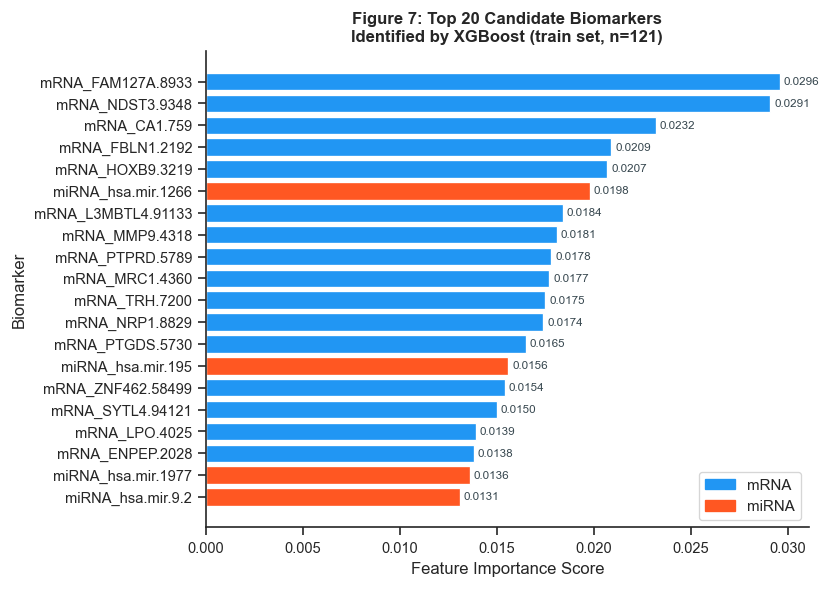

[OUTPUT] Figure 7 saved → Figure7_Top20_Biomarkers.tiff

--- SECTION 7 COMPLETE ---

[OUTPUT] Biomarker table saved → AML_XGBoost_Top20_Biomarkers.csv

Biomarker table saved successfully.


In [67]:
# ============================================================
# SECTION 7: BIOMARKER DISCOVERY USING XGBOOST
# ============================================================

print("\n--- SECTION 7: BIOMARKER DISCOVERY USING XGBOOST ---")

# ------------------------------------------------------------
# 1. Train final XGBoost model
# ------------------------------------------------------------
final_model = clone(xgb_classifier)
final_model.fit(X_train, y_train)

# ------------------------------------------------------------
# 2. Extract feature importance scores
# ------------------------------------------------------------
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

# ------------------------------------------------------------
# 3. Rank features
# ------------------------------------------------------------

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# ------------------------------------------------------------
# 4. Select Top 20 biomarkers
# ------------------------------------------------------------

top20 = importance_df.head(20).copy()
top20.reset_index(drop=True, inplace=True)
top20["Importance"] = top20["Importance"].round(4)


# ------------------------------------------------------------
# 5. Classify molecular type
# ------------------------------------------------------------

top20["Molecule_Type"] = np.where(
    top20["Feature"].str.contains("mir", case=False),
    "miRNA",
    "mRNA"
)

# ------------------------------------------------------------
# 6. Display candidate biomarkers
# ------------------------------------------------------------


print("\nTop 20 Candidate Biomarkers")
display(top20)

# ------------------------------------------------------------
# 7. Biomarker summary
# ------------------------------------------------------------

print("\nBiomarker Summary")
print(f"Total biomarkers identified: {len(top20)}")
print(
    f"mRNA biomarkers: {(top20['Molecule_Type']=='mRNA').sum()}"
)
print(
    f"miRNA biomarkers: {(top20['Molecule_Type']=='miRNA').sum()}"
)

# ------------------------------------------------------------
# 8. Visualization
# ------------------------------------------------------------

bar_colors = ['#2196F3' if t == 'mRNA' else '#FF5722'
              for t in top20['Molecule_Type']]

fig7, ax7 = plt.subplots(figsize=(7, 5))
bars = ax7.barh(top20['Feature'][::-1], top20['Importance'][::-1],
                color=bar_colors[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, top20['Importance'][::-1]):
    ax7.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=7, color='#37474F')
ax7.set_xlabel('Feature Importance Score', fontsize=10)
ax7.set_ylabel('Biomarker', fontsize=10)
ax7.set_title('Figure 7: Top 20 Candidate Biomarkers\nIdentified by XGBoost (train set, n=121)',
              fontsize=10, fontweight='bold')
ax7.legend(handles=[
    mpatches.Patch(color='#2196F3', label='mRNA'),
    mpatches.Patch(color='#FF5722', label='miRNA')
], fontsize=9, frameon=True, loc='lower right')
sns.despine(ax=ax7)
plt.tight_layout()
plt.savefig('Figure7_Top20_Biomarkers.tiff', bbox_inches='tight', dpi=300)
plt.show()
print("[OUTPUT] Figure 7 saved → Figure7_Top20_Biomarkers.tiff")
print("\n--- SECTION 7 COMPLETE ---")

# ------------------------------------------------------------
# 9. Save results
# ------------------------------------------------------------

top20.to_csv('AML_XGBoost_Top20_Biomarkers.csv', index=False)
print("\n[OUTPUT] Biomarker table saved → AML_XGBoost_Top20_Biomarkers.csv")

print("\nBiomarker table saved successfully.")

## **Interpretation:**

XGBoost achieved the strongest predictive performance among the evaluated machine learning models and was therefore selected for biomarker discovery. Feature importance analysis identified 20 candidate biomarkers associated with AML survival prediction, including 16 mRNA features and 4 miRNA features.

The identification of both coding genes and regulatory miRNAs among the top predictors suggests that multiple molecular mechanisms contribute to AML prognosis. While several biomarkers may already be linked to cancer-related pathways, others remain less characterized and may represent promising targets for future investigation.

These findings demonstrate that integrating transcriptomic and regulatory molecular information can improve biomarker discovery and provide biologically meaningful insights into disease heterogeneity within AML.

## **Section 8: Kaplan-Meier Survival Analysis**

In [72]:
!pip install lifelines

In [10]:
predicted_class = final_model.predict(X_test)
survival_df = pd.DataFrame({
    "PatientID": X_test.index,
    "Survival": clinical_survival.loc[X_test.index],
    "Death": clinical_death.loc[X_test.index],
    "PredictedGroup": predicted_class
})



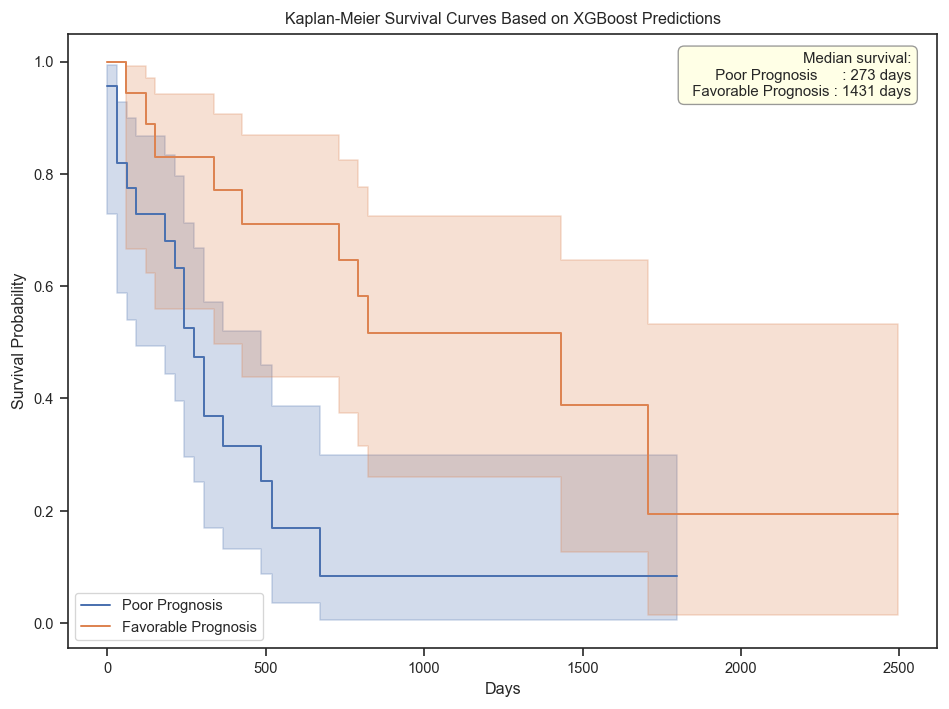

Log-rank p-value: 0.0044


In [71]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

kmf = KaplanMeierFitter()
plt.figure(figsize=(8,6))
for group in [0,1]:
    mask = survival_df["PredictedGroup"] == group
    kmf.fit(
        durations=survival_df.loc[mask, "Survival"],
        event_observed=survival_df.loc[mask, "Death"],
        label="Poor Prognosis" if group == 0 else "Favorable Prognosis"
    )
    kmf.plot_survival_function()
    if group == 0:
        med_poor = kmf.median_survival_time_
    else:
        med_fav = kmf.median_survival_time_

plt.title("Kaplan-Meier Survival Curves Based on XGBoost Predictions")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.text(0.97, 0.97,
         f'Median survival:\n'
         f'  Poor Prognosis      : {med_poor:.0f} days\n'
         f'  Favorable Prognosis : {med_fav:.0f} days',
         transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                   edgecolor='grey', alpha=0.8))
plt.tight_layout()
plt.savefig("Figure8_Kaplan_Meier.tiff", dpi=300, bbox_inches='tight')
plt.show()

group0  = survival_df["PredictedGroup"] == 0
group1  = survival_df["PredictedGroup"] == 1
results = logrank_test(
    survival_df.loc[group0, "Survival"],
    survival_df.loc[group1, "Survival"],
    event_observed_A=survival_df.loc[group0, "Death"],
    event_observed_B=survival_df.loc[group1, "Death"]
)
print(f"Log-rank p-value: {results.p_value:.4f}")

## **Interpretation:**

Kaplan-Meier survival analysis was performed to evaluate whether the patient groups predicted by the XGBoost model exhibited different survival outcomes.

A statistically significant separation between the two predicted groups was observed (log-rank p = 0.0044). Patients classified into the favorable prognosis group showed consistently higher survival probabilities over time, whereas patients assigned to the poor prognosis group experienced shorter survival durations.

These findings indicate that the molecular patterns learned from the integrated mRNA and miRNA data are associated with clinically meaningful differences in patient survival. The significant Kaplan-Meier separation provides additional evidence that the XGBoost model captures biologically relevant prognostic information rather than random patterns in the data.

Overall, the results support the potential utility of multi-omics integration and machine learning for AML risk stratification and precision medicine applications